In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms

# Grad-CAM Library
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

from utils.model import load_model 
import config_potamogaton as cfg
import utils.data as data_utils

MODEL_PATH = cfg.best_model_path
model = load_model(MODEL_PATH)
model.eval()
print("Ready to use model")

# Get the test dataloader
# We use get_single_dataloader and then ensure batch size is 1 for easy iteration
test_dataloader_full = data_utils.get_single_dataloader(cfg, data_dir=cfg.main_data_dir)
test_dataloader = data_utils.make_batch_size_one(test_dataloader_full)

print("\nModel and Dataloader are ready.")

/home/takayuki/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
/home/takayuki/.local/lib/python3.10/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


Model loaded successfully from /home/takayuki/Desktop/summer2025/plants/training/potamogaton/models/best_loss_model_09-05_17-25--58_a1_potamogaton_convnextv2_tiny.fcmae_ft_in22k_in1k.pth
Ready to use model
Using the entire dataset as the test set. No train/val split.
Inspecting directory: /home/takayuki/Desktop/summer2025/plants/plant_classification/../data/AquaticPlantLabData/potamogaton
Found 7 classes locally: ['Potamogeton crispus', 'Potamogeton gramineus', 'Potamogeton illinoensis', 'Potamogeton natans', 'Potamogeton praelongus', 'Potamogeton richardsonii', 'Potamogeton robbinsii']
Remapped 105 images to use canonical indices.
Total dataset size 	: 105
Calculated train size 	: 0
Calculated val size 	: 0
Calculated test size 	: 105

Test DataLoader created with 105 images from /home/takayuki/Desktop/summer2025/plants/plant_classification/../data/AquaticPlantLabData/potamogaton.

Model and Dataloader are ready.


In [ ]:
# IMAGE_PATH = '/home/takayuki/Desktop/summer2025/plants/data/AquaticPlantLabData/potamogaton/Potamogeton crispus/Curlyleaf Pondweed 1.JPG'

# # Find the target layer you want to visualize
# # Example for a ConvNeXt model: model.backbone.stages[-1]
# # Example for a ResNet model: model.layer4[-1]
# target_layers = [model.model.stages[-1]] # The library takes a list of layers

# # --- Cell 3: Prepare the Image ---
# rgb_img = Image.open(IMAGE_PATH).convert('RGB')
# input_tensor = data_utils.image_to_tensor(cfg, rgb_img) # Use your helper to normalize and add batch dim

# # --- Cell 4: Generate Grad-CAM with the Library ---
# # 1. Create a GradCAM object
# cam = GradCAM(model=model, target_layers=target_layers)

# # 2. Define the target for the CAM. Here, we want to see why it predicted a specific class.
# # If you don't specify a target, it will default to the predicted class.
# targets = [ClassifierOutputTarget(2)] # Example: see why it thought this was class index 2

# # 3. Generate the CAM
# grayscale_cam = cam(input_tensor=input_tensor, targets=targets)

# # 4. Get the first (and only) CAM in the batch
# grayscale_cam = grayscale_cam[0, :]

# # --- Cell 5: Visualize the Result ---
# # The library provides a handy visualization function.
# # Note: It needs the image as a numpy array scaled to [0, 1]
# # Let's resize the original PIL image to match the model input size for clean overlay
# vis_img = rgb_img.resize((224, 224))
# vis_img_float = np.float32(vis_img) / 255

# cam_image = show_cam_on_image(vis_img_float, grayscale_cam, use_rgb=True)

# plt.imshow(cam_image)
# plt.title("Grad-CAM Overlay")
# plt.axis('off')
# plt.show()

In [ ]:
# # ===================================================================
# # Cell 1: Imports and Setup
# # ===================================================================
# import torch
# import numpy as np
# import matplotlib.pyplot as plt
# from PIL import Image
# from torchvision import transforms

# # Grad-CAM Library
# from pytorch_grad_cam import GradCAM
# from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
# from pytorch_grad_cam.utils.image import show_cam_on_image


# # Get the test dataloader
# # We use get_single_dataloader and then ensure batch size is 1 for easy iteration
# test_dataloader_full = data_utils.get_single_dataloader(cfg, data_dir=cfg.main_data_dir)
# test_dataloader = data_utils.make_batch_size_one(test_dataloader_full)

# print("\nModel and Dataloader are ready.")

# # ===================================================================
# # Cell 3: The Reusable Grad-CAM Grid Function
# # ===================================================================
# def display_gradcam_grid(model, dataloader, cfg, num_images=10, cols=5):
#     """
#     Generates and displays a grid of Grad-CAM overlays for images from a dataloader.

#     Args:
#         model (torch.nn.Module): The trained model.
#         dataloader (DataLoader): Dataloader with batch size 1.
#         cfg (module): The project configuration file.
#         num_images (int): The number of images to display.
#         cols (int): The number of columns in the display grid.
#     """
#     # --- IMPORTANT WORKAROUND ---
#     # As you noted, your LinearBaselineModel uses 'model' instead of 'backbone'.
#     # This code handles that inconsistency. The long-term fix is in utils/model.py.
#     if hasattr(model, 'backbone'):
#         feature_extractor = model.backbone
#     elif hasattr(model, 'model'):
#         feature_extractor = model.model
#     else:
#         raise AttributeError("Model has no 'backbone' or 'model' attribute to target for Grad-CAM.")
        
#     # We will target the last stage of the feature extractor
#     target_layers = [feature_extractor.stages[-1]]
    
#     # Initialize Grad-CAM
#     cam = GradCAM(model=model, target_layers=target_layers)
    
#     device = next(model.parameters()).device
#     results = []

#     # --- Collect images and generate CAMs ---
#     print(f"Generating Grad-CAM for {num_images} images...")
#     for i, (image_tensor, label) in enumerate(dataloader):
#         if i >= num_images:
#             break
            
#         input_tensor = image_tensor.to(device)
#         true_label_idx = label.item()
        
#         # Get the model's prediction
#         with torch.no_grad():
#             logits = model(input_tensor)
#             pred_label_idx = logits.argmax().item()

#         # Generate CAM for the predicted class
#         targets = [ClassifierOutputTarget(pred_label_idx)]
#         grayscale_cam = cam(input_tensor=input_tensor, targets=targets, aug_smooth=True, eigen_smooth=True)
#         grayscale_cam = grayscale_cam[0, :] # Get the first (and only) CAM

#         # Prepare original image for visualization (HWC, uint8)
#         original_img_np = data_utils.to_uint8_img(cfg, input_tensor)
        
#         # Use the library's overlay function, which needs a float [0,1] image
#         original_img_float = original_img_np.astype(np.float32) / 255
#         cam_overlay = show_cam_on_image(original_img_float, grayscale_cam, use_rgb=True)

#         results.append({
#             'original': original_img_np,
#             'overlay': cam_overlay,
#             'true_label_idx': true_label_idx,
#             'pred_label_idx': pred_label_idx
#         })

#     # --- Plotting the grid ---
#     if not results:
#         print("No images were processed.")
#         return

#     rows = (len(results) * 2 + cols - 1) // cols # Each image takes 2 spots (original + CAM)
#     fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 2.5))
#     axes = axes.flatten()
    
#     class_names = cfg.CANONICAL_CLASSNAMES_LIST

#     for i, res in enumerate(results):
#         # Plot Original Image
#         ax_orig = axes[i * 2]
#         ax_orig.imshow(res['original'])
#         ax_orig.set_title(f"Original Image\nTrue: {class_names[res['true_label_idx']]}", fontsize=9)
#         ax_orig.axis('off')

#         # Plot Grad-CAM Overlay
#         ax_cam = axes[i * 2 + 1]
#         ax_cam.imshow(res['overlay'])
#         pred_is_correct = res['true_label_idx'] == res['pred_label_idx']
#         title_color = 'green' if pred_is_correct else 'red'
#         ax_cam.set_title(f"Grad-CAM Overlay\nPred: {class_names[res['pred_label_idx']]}", color=title_color, fontsize=9)
#         ax_cam.axis('off')

#     # Hide any unused subplots
#     for j in range(len(results) * 2, len(axes)):
#         axes[j].axis('off')

#     plt.tight_layout()
#     plt.show()


# # ===================================================================
# # Cell 4: Run the Visualization
# # ===================================================================
# display_gradcam_grid(
#     model=model,
#     dataloader=test_dataloader,
#     cfg=cfg,
#     num_images=10, # You can change this number
#     cols=4           # You can change the number of columns
# )

Generating Grad-CAM for 4 images...


/tmp/ipykernel_35128/3747855463.py:113: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust layout to not overlap with colorbar


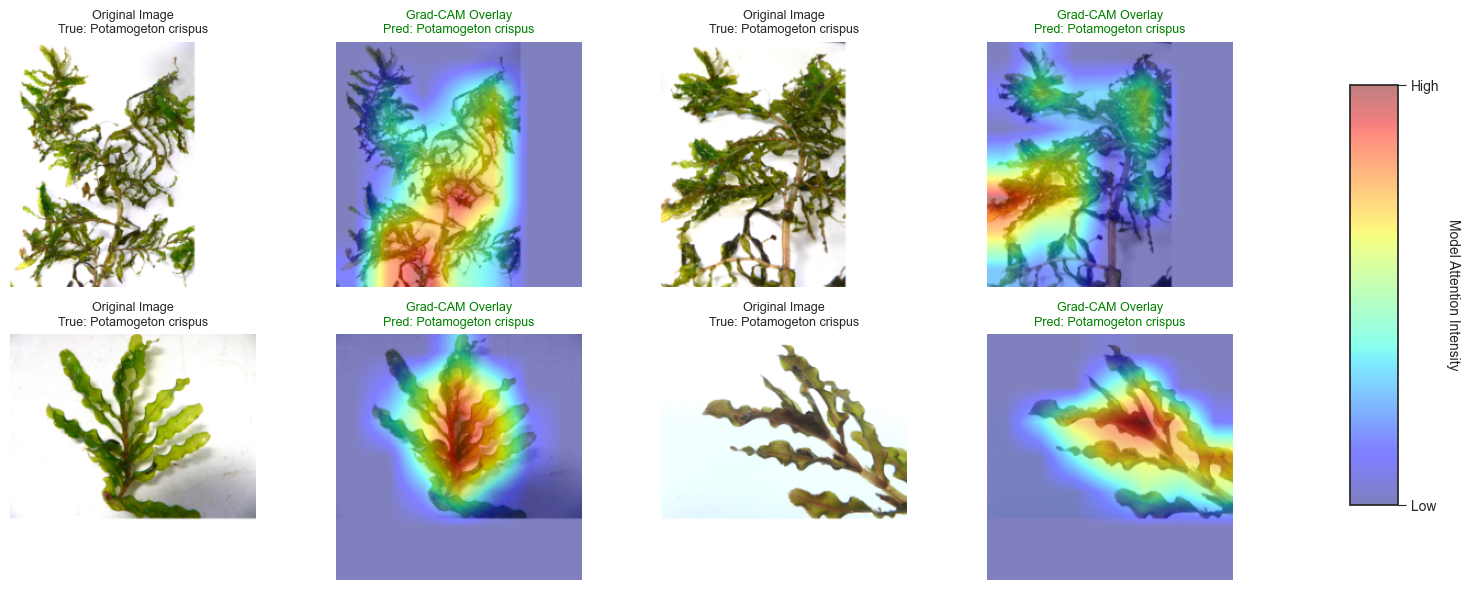

In [3]:
# ===================================================================
# Cell 3: The Reusable Grad-CAM Grid Function (with Colorbar)
# ===================================================================
import cv2 # We'll use OpenCV for quick resizing

def display_gradcam_grid(model, dataloader, cfg, num_images=10, cols=5):
    """
    Generates and displays a grid of Grad-CAM overlays with a shared colorbar.

    Args:
        model (torch.nn.Module): The trained model.
        dataloader (DataLoader): Dataloader with batch size 1.
        cfg (module): The project configuration file.
        num_images (int): The number of images to display.
        cols (int): The number of columns in the display grid.
    """
    # --- Workaround for inconsistent model attribute names ---
    if hasattr(model, 'backbone'):
        feature_extractor = model.backbone
    elif hasattr(model, 'model'):
        feature_extractor = model.model
    else:
        raise AttributeError("Model has no 'backbone' or 'model' attribute to target for Grad-CAM.")
        
    target_layers = [feature_extractor.stages[-1]]
    cam = GradCAM(model=model, target_layers=target_layers)
    
    device = next(model.parameters()).device
    results = []

    # --- Collect images and generate RAW heatmaps ---
    print(f"Generating Grad-CAM for {num_images} images...")
    for i, (image_tensor, label) in enumerate(dataloader):
        if i >= num_images:
            break
            
        input_tensor = image_tensor.to(device)
        true_label_idx = label.item()
        
        with torch.no_grad():
            logits = model(input_tensor)
            pred_label_idx = logits.argmax().item()

        targets = [ClassifierOutputTarget(pred_label_idx)]
        grayscale_cam = cam(input_tensor=input_tensor, targets=targets, aug_smooth=True, eigen_smooth=True)
        grayscale_cam = grayscale_cam[0, :]

        original_img_np = data_utils.to_uint8_img(cfg, input_tensor)
        
        ## CHANGE: Instead of creating the overlay now, we store the raw heatmap
        results.append({
            'original': original_img_np,
            'heatmap': grayscale_cam, # <-- Store the raw heatmap
            'true_label_idx': true_label_idx,
            'pred_label_idx': pred_label_idx
        })

    # --- Plotting the grid ---
    if not results:
        print("No images were processed.")
        return

    rows = (len(results) * 2 + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3))
    axes = axes.flatten()
    
    class_names = cfg.CANONICAL_CLASSNAMES_LIST
    
    # This will hold the last plotted heatmap image, which we need for the colorbar
    last_mappable = None

    for i, res in enumerate(results):
        # Plot Original Image
        ax_orig = axes[i * 2]
        ax_orig.imshow(res['original'])
        ax_orig.set_title(f"Original Image\nTrue: {class_names[res['true_label_idx']]}", fontsize=9)
        ax_orig.axis('off')

        # Plot Grad-CAM Overlay MANUALLY
        ax_cam = axes[i * 2 + 1]
        
        # 1. Plot the original image as the base layer
        ax_cam.imshow(res['original'])
        
        # 2. Resize the heatmap to match the image dimensions
        resized_heatmap = cv2.resize(res['heatmap'], (res['original'].shape[1], res['original'].shape[0]))
        
        # 3. Plot the heatmap on top with transparency and a colormap
        #    We save the returned object to create the colorbar later
        last_mappable = ax_cam.imshow(resized_heatmap, cmap='jet', alpha=0.5)
        
        pred_is_correct = res['true_label_idx'] == res['pred_label_idx']
        title_color = 'green' if pred_is_correct else 'red'
        ax_cam.set_title(f"Grad-CAM Overlay\nPred: {class_names[res['pred_label_idx']]}", color=title_color, fontsize=9)
        ax_cam.axis('off')

    # Hide any unused subplots
    for j in range(len(results) * 2, len(axes)):
        axes[j].axis('off')

    # --- Add the Colorbar ---
    if last_mappable:
        # Create a new axis for the colorbar to avoid shrinking the last plot
        fig.subplots_adjust(right=0.85) # Make room for the colorbar
        cbar_ax = fig.add_axes([0.88, 0.15, 0.03, 0.7]) # [left, bottom, width, height]
        
        # Add the colorbar using the last mappable object
        cbar = fig.colorbar(last_mappable, cax=cbar_ax)
        cbar.set_label('Model Attention Intensity', rotation=270, labelpad=15)
        cbar.set_ticks([0, 1])
        cbar.set_ticklabels(['Low', 'High'])

    plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust layout to not overlap with colorbar
    plt.show()


# ===================================================================
# Cell 4: Run the Visualization
# ===================================================================
# You call the function exactly as before. The new version will automatically add the colorbar.
display_gradcam_grid(
    model=model,
    dataloader=test_dataloader,
    cfg=cfg,
    num_images=4,
    cols=4
)

Found 4 stages in model backbone.
Generating Grad-CAMs for 10 images across 4 layers...


/tmp/ipykernel_35128/995622413.py:146: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1]) # Adjust layout


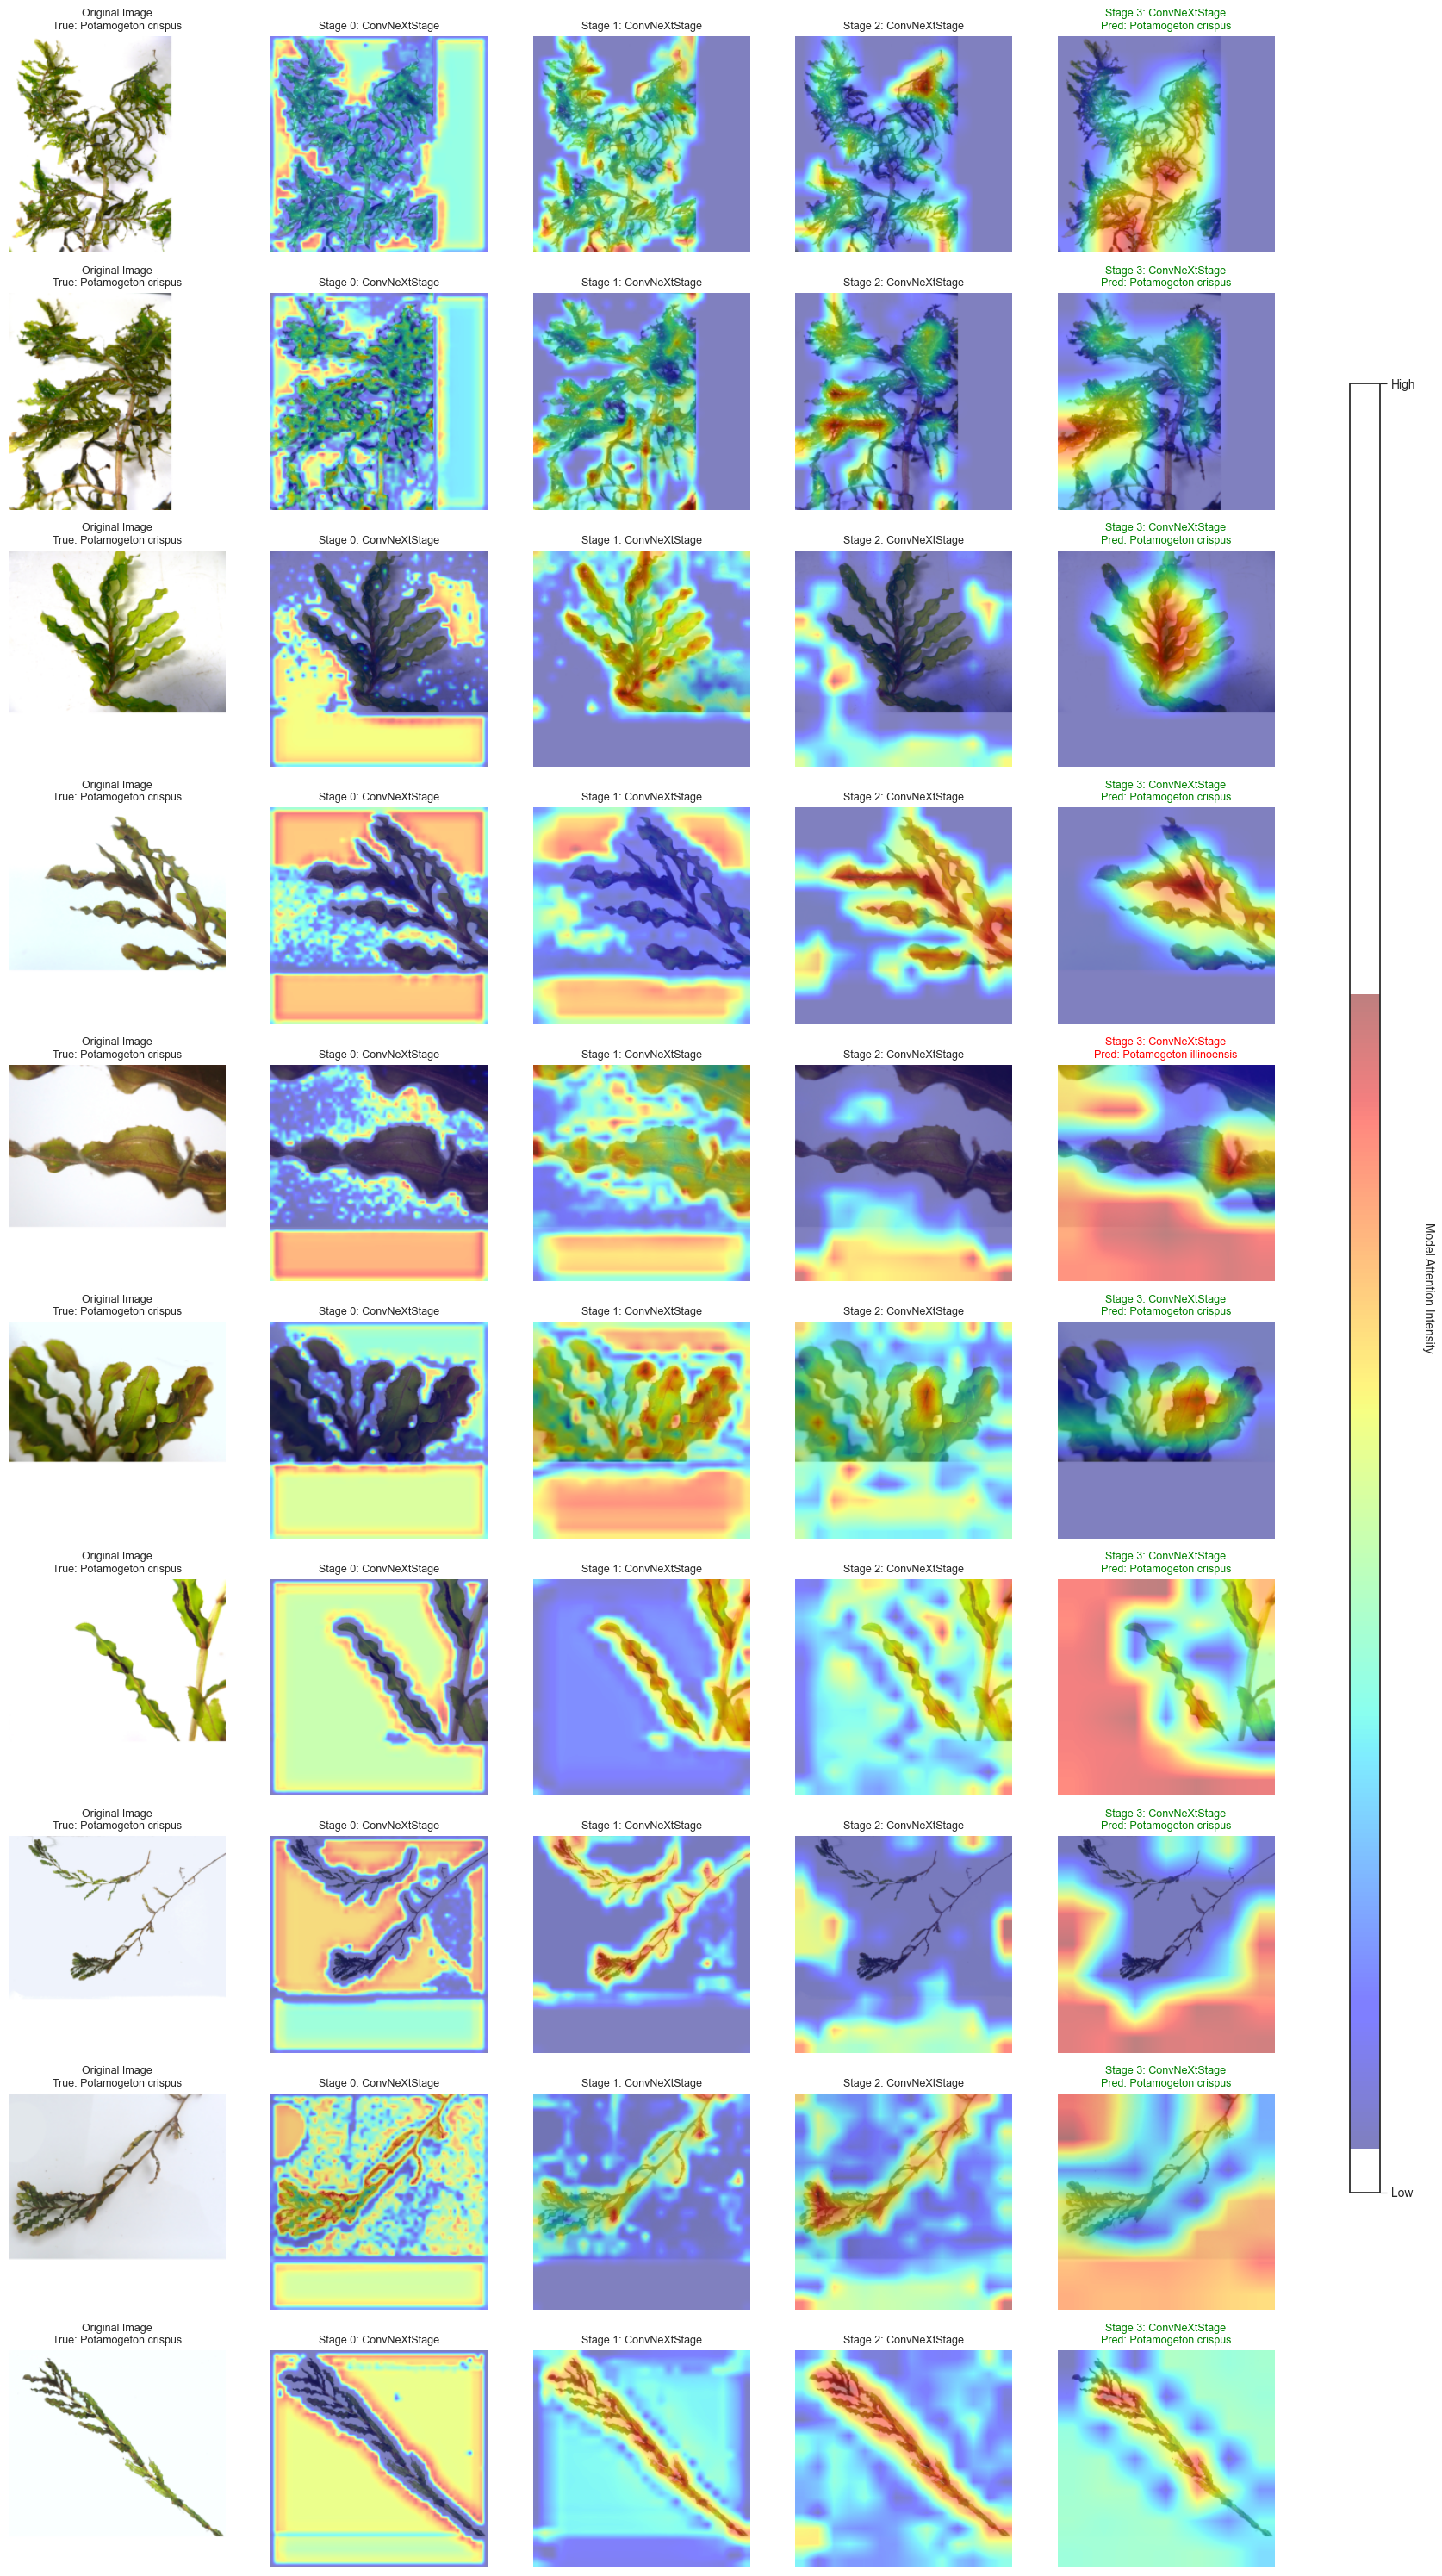

In [5]:
# ===================================================================
# Cell 5: The New Multi-Layer Grad-CAM Visualization Function
# ===================================================================
import math
import cv2 # We'll use OpenCV for quick resizing

def get_equally_spaced_layers(module_list, num_layers):
    """Selects a number of equally spaced modules from a list."""
    if num_layers > len(module_list):
        print(f"Warning: Requesting {num_layers} layers, but only {len(module_list)} are available. Using all available layers.")
        return module_list, [f"Layer {i}" for i in range(len(module_list))]
    
    indices = np.linspace(0, len(module_list) - 1, num_layers, dtype=int)
    selected_layers = [module_list[i] for i in indices]
    
    # Create descriptive names for titles
    layer_names = []
    for i in indices:
      # Try to get a meaningful name, otherwise just use the index
      try:
        layer_names.append(f"Stage {i}: {type(module_list[i]).__name__}")
      except:
        layer_names.append(f"Layer Index {i}")

    return selected_layers, layer_names

def display_multilayer_gradcam(model, dataloader, cfg, num_images=3, num_layers=5):
    """
    Generates and displays a grid of Grad-CAM overlays for multiple layers of the model.
    Each row corresponds to one image, showing the original followed by heatmaps
    from progressively deeper layers.

    Args:
        model (torch.nn.Module): The trained model.
        dataloader (DataLoader): Dataloader with batch size 1.
        cfg (module): The project configuration file.
        num_images (int): The number of images (rows) to display.
        num_layers (int): The number of layers (Grad-CAMs per image) to display.
    """
    # --- 1. Identify Backbone and Select Target Layers ---
    if hasattr(model, 'backbone'):
        feature_extractor = model.backbone
    elif hasattr(model, 'model'):
        feature_extractor = model.model
    else:
        raise AttributeError("Model has no 'backbone' or 'model' attribute to target for Grad-CAM.")
        
    # Most timm models have a 'stages' or 'blocks' attribute which is a ModuleList
    candidate_layers = None
    if hasattr(feature_extractor, 'stages'):
        candidate_layers = feature_extractor.stages
        print(f"Found {len(candidate_layers)} stages in model backbone.")
    elif hasattr(feature_extractor, 'blocks'):
        candidate_layers = feature_extractor.blocks
        print(f"Found {len(candidate_layers)} blocks in model backbone.")
    else:
        raise AttributeError("Could not find 'stages' or 'blocks' in the model's feature extractor. Please specify layers manually.")
    
    target_layers, layer_names = get_equally_spaced_layers(candidate_layers, num_layers)

    device = next(model.parameters()).device
    results = []

    # --- 2. Collect Images and Generate Heatmaps for Each Layer ---
    print(f"Generating Grad-CAMs for {num_images} images across {len(target_layers)} layers...")
    for i, (image_tensor, label) in enumerate(dataloader):
        if i >= num_images:
            break
            
        input_tensor = image_tensor.to(device)
        true_label_idx = label.item()
        
        # Get model prediction once per image
        with torch.no_grad():
            logits = model(input_tensor)
            pred_label_idx = logits.argmax().item()

        targets = [ClassifierOutputTarget(pred_label_idx)]
        original_img_np = data_utils.to_uint8_img(cfg, input_tensor)
        
        # Generate a heatmap for each target layer
        heatmaps = []
        for layer in target_layers:
            # Each GradCAM instance is specific to a set of target layers
            cam = GradCAM(model=model, target_layers=[layer]) 
            grayscale_cam = cam(input_tensor=input_tensor, targets=targets, aug_smooth=True, eigen_smooth=True)
            heatmaps.append(grayscale_cam[0, :])

        results.append({
            'original': original_img_np,
            'heatmaps': heatmaps,
            'true_label_idx': true_label_idx,
            'pred_label_idx': pred_label_idx
        })

    # --- 3. Plotting the Grid ---
    if not results:
        print("No images were processed.")
        return
    
    cols = num_layers + 1  # 1 for original image + num_layers for CAMs
    rows = num_images
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.5, rows * 3))
    # Ensure axes is always a 2D array for consistent indexing
    if rows == 1:
        axes = np.expand_dims(axes, axis=0)
        
    class_names = cfg.CANONICAL_CLASSNAMES_LIST
    last_mappable = None # For the colorbar

    for i, res in enumerate(results): # Iterate through rows (images)
        # Plot Original Image in the first column
        ax_orig = axes[i, 0]
        ax_orig.imshow(res['original'])
        ax_orig.set_title(f"Original Image\nTrue: {class_names[res['true_label_idx']]}", fontsize=9)
        ax_orig.axis('off')
        
        # Plot Grad-CAM overlays for each layer
        for j, heatmap in enumerate(res['heatmaps']):
            ax_cam = axes[i, j + 1]
            ax_cam.imshow(res['original']) # Base image
            
            resized_heatmap = cv2.resize(heatmap, (res['original'].shape[1], res['original'].shape[0]))
            last_mappable = ax_cam.imshow(resized_heatmap, cmap='jet', alpha=0.5) # Overlay
            
            # Add layer name title to each CAM plot
            ax_cam.set_title(layer_names[j], fontsize=9)
            ax_cam.axis('off')

        # Add the final prediction title to the last CAM plot of the row
        pred_is_correct = res['true_label_idx'] == res['pred_label_idx']
        title_color = 'green' if pred_is_correct else 'red'
        final_cam_ax = axes[i, -1]
        current_title = final_cam_ax.get_title()
        final_cam_ax.set_title(f"{current_title}\nPred: {class_names[res['pred_label_idx']]}", color=title_color, fontsize=9)

    # --- 4. Add Shared Colorbar ---
    if last_mappable:
        fig.subplots_adjust(right=0.9)
        cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
        cbar = fig.colorbar(last_mappable, cax=cbar_ax)
        cbar.set_label('Model Attention Intensity', rotation=270, labelpad=15)
        cbar.set_ticks([0, 1])
        cbar.set_ticklabels(['Low', 'High'])

    plt.tight_layout(rect=[0, 0, 0.9, 1]) # Adjust layout
    plt.show()


# ===================================================================
# Cell 6: Run the New Multi-Layer Visualization
# ===================================================================
# This call will produce a grid with 3 rows (one for each image) and 
# 6 columns (1 original + 5 Grad-CAMs).
display_multilayer_gradcam(
    model=model,
    dataloader=test_dataloader, # Make sure test_dataloader is defined and has batch_size=1
    cfg=cfg,
    num_images=10,
    num_layers=4 
)